In [1]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [3]:
df = pd.read_csv('/content/drive/My Drive/Customer Churn Data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Understanding

In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Data Cleaning

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [10]:
df.dropna(inplace=True)

In [11]:
#Remove useless column
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

Target Encoding

In [12]:
df['Churn'] = df['Churn'].map(
    {
        "Yes":1,
        "No":0
    }
)

In [13]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


Exploratory Data Analysis

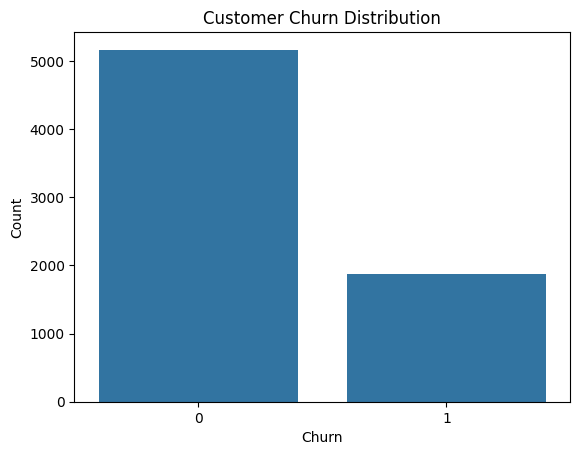

In [28]:
sns.countplot(
    x='Churn',
    data=df
)
plt.xlabel("Churn")
plt.ylabel("Count")
plt.title(
    "Customer Churn Distribution"
)
plt.show()

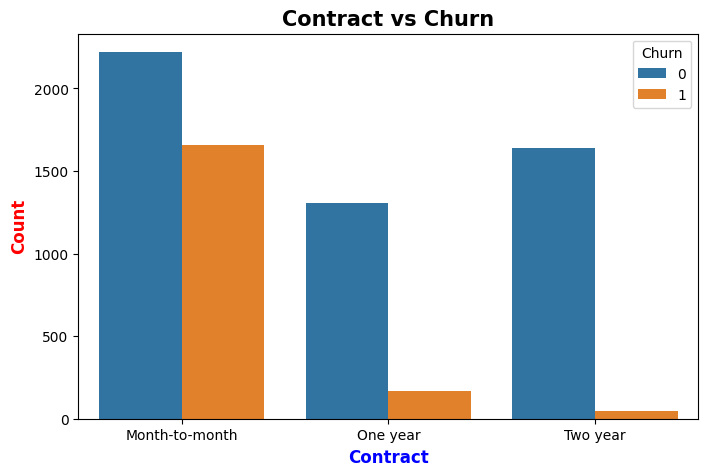

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xlabel("Contract", fontsize=12, fontweight='bold', color='blue')
plt.ylabel("Count", fontsize=12, fontweight='bold', color='red')
plt.title("Contract vs Churn", fontsize=15, fontweight='bold')

plt.xticks(rotation=0)
plt.show()

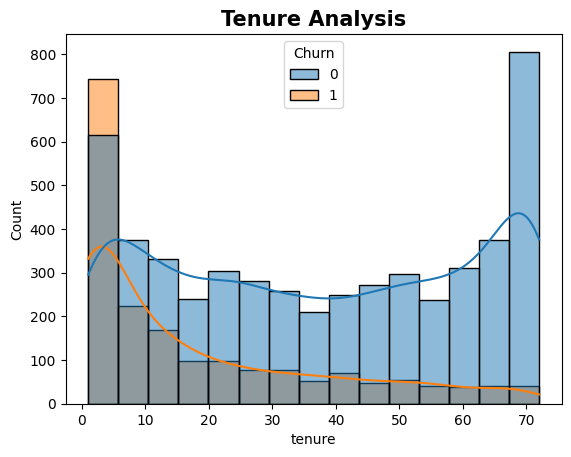

In [27]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)
plt.title("Tenure Analysis", fontsize=15, fontweight='bold')
plt.show()

Feature Engineering

In [29]:
df['CustomerValue'] = (
    df['tenure'] *
    df['MonthlyCharges']
)

In [30]:
def risk(value):
    if value < 12:
        return "New Customer"

    elif value < 36:
        return "Medium"

    else:
        return "Loyal"

df['CustomerType'] = df['tenure'].apply(risk)

Preprocessing Pipeline

In [31]:
X = df.drop(
    "Churn",
    axis=1
)

y=df['Churn']

In [32]:
cat_cols = X.select_dtypes(
    include="object"
).columns

num_cols = X.select_dtypes(
    exclude="object"
).columns

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
[
(
"cat",
OneHotEncoder(
drop="first"
),
cat_cols
),

(
"num",
StandardScaler(),
num_cols
)
]
)

Train Test Split

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(

X, y, test_size=0.2, random_state=42,
stratify=y
)

Model Training

In [35]:
from xgboost import XGBClassifier
model = XGBClassifier(

n_estimators=300,
learning_rate=0.05,
max_depth=5,
random_state=42

)

ML Pipeline

In [36]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
steps=[
(
"preprocessing",
preprocessor
),

(
"model",
model
)
]
)

Train

In [37]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'CustomerType'],
      dty...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

Evaluation

In [38]:
y_pred = pipeline.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.7860696517412935

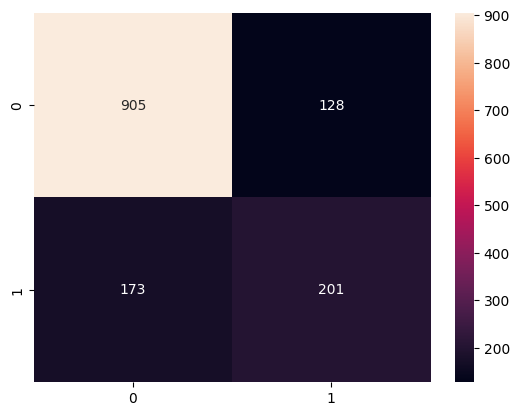

In [40]:
from sklearn.metrics import confusion_matrix

sns.heatmap(
confusion_matrix(y_test,y_pred),
annot=True,
fmt='d'
)

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(
classification_report(y_test,y_pred)
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Model Explainability

 97%|=================== | 1364/1407 [00:27<00:00]       

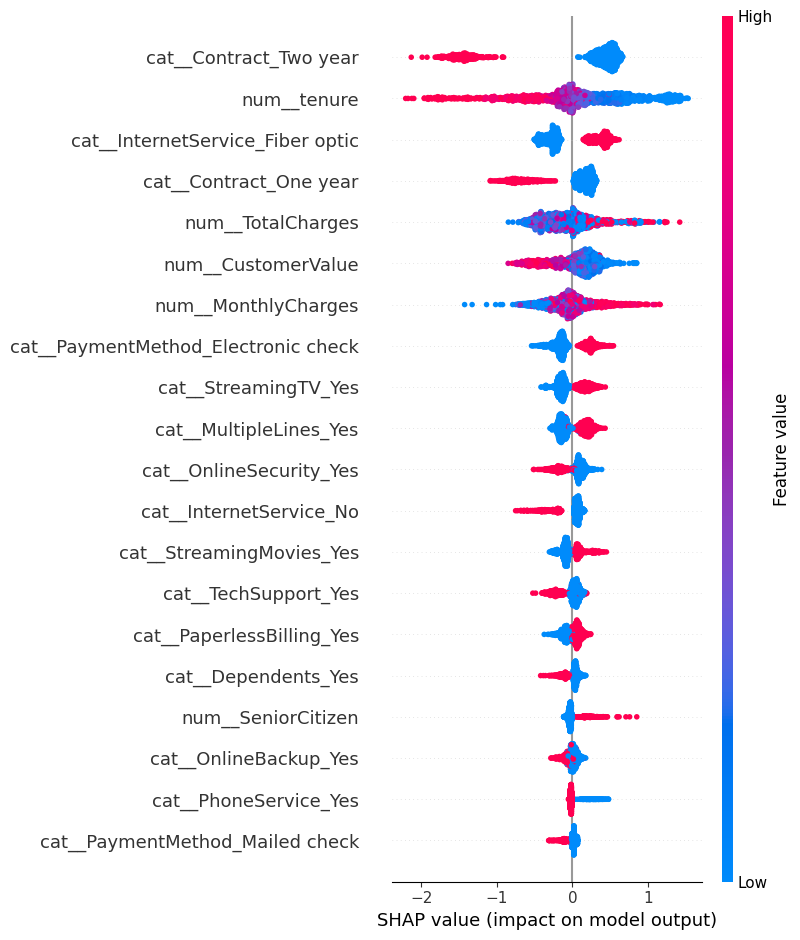

In [44]:
import shap
import pandas as pd
import numpy as np

# Get the fitted preprocessor and model from the pipeline
fitted_preprocessor = pipeline.named_steps['preprocessing']
xgb_model = pipeline.named_steps['model']

# Transform X_train and X_test using the fitted preprocessor
# This ensures all data passed to the TreeExplainer is numerical
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get the feature names after preprocessing for better plotting
# OneHotEncoder adds new features, so we need to get their names.
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

# Create the TreeExplainer with the actual XGBoost model and transformed training data
explainer = shap.TreeExplainer(xgb_model, X_train_transformed)

# Calculate SHAP values for the transformed test data
values = explainer.shap_values(X_test_transformed)

# Check if values is a list (typical for TreeExplainer with binary classification)
# or a single 2D array (as implied by the kernel state in the previous run).
# The goal is to get a 2D array of shape (n_samples, n_features) for the target class.
if isinstance(values, list) and len(values) == 2 and isinstance(values[1], np.ndarray) and values[1].ndim == 2:
    # This is the standard behavior for binary classification, take the positive class (index 1)
    shap_values_to_plot = values[1]
elif isinstance(values, np.ndarray) and values.ndim == 2:
    # If 'values' is already a single 2D array, it's likely the SHAP values for the target class.
    shap_values_to_plot = values
else:
    raise TypeError(f"Unexpected type or dimension for SHAP values: type={type(values)}, ndim={getattr(values, 'ndim', 'N/A')}")

# Plot the summary for the positive class (churn = 1)
shap.summary_plot(shap_values_to_plot, X_test_transformed, feature_names=transformed_feature_names)


Customer Segmentation

In [48]:
from sklearn.cluster import KMeans

features=df[
[
"tenure",
"MonthlyCharges",
"TotalCharges"
]
]
kmeans=KMeans(
n_clusters=3,
random_state=42
)
df['Segment']=kmeans.fit_predict(features)

Save Model

In [45]:
import joblib
import os

# Define the directory path
model_dir = "../models/"

# Create the directory if it does not exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

joblib.dump(
pipeline,
os.path.join(model_dir, "churn_model.pkl")
)

['../models/churn_model.pkl']

In [46]:
from google.colab import files

# Save trained model
joblib.dump(
    pipeline,
    "churn_model.pkl"
)

# Download model to your computer
files.download(
    "churn_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>